In [ ]:
# ============================================================
# BLOCK 1: Install Dependencies & Imports
# ============================================================

!pip install tensorflow numpy matplotlib Pillow opencv-python-headless -q

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
import time
from IPython.display import display, Image as IPImage
from PIL import Image, ImageOps, ImageFilter
import cv2
import io
import warnings
warnings.filterwarnings('ignore')

print("✅ TensorFlow version:", tf.__version__)
print("✅ All libraries loaded successfully!")

✅ TensorFlow version: 2.19.0
✅ All libraries loaded successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Training samples : 60000
✅ Test samples     : 10000
✅ Input shape      : (28, 28, 1)
✅ Output classes   : 10


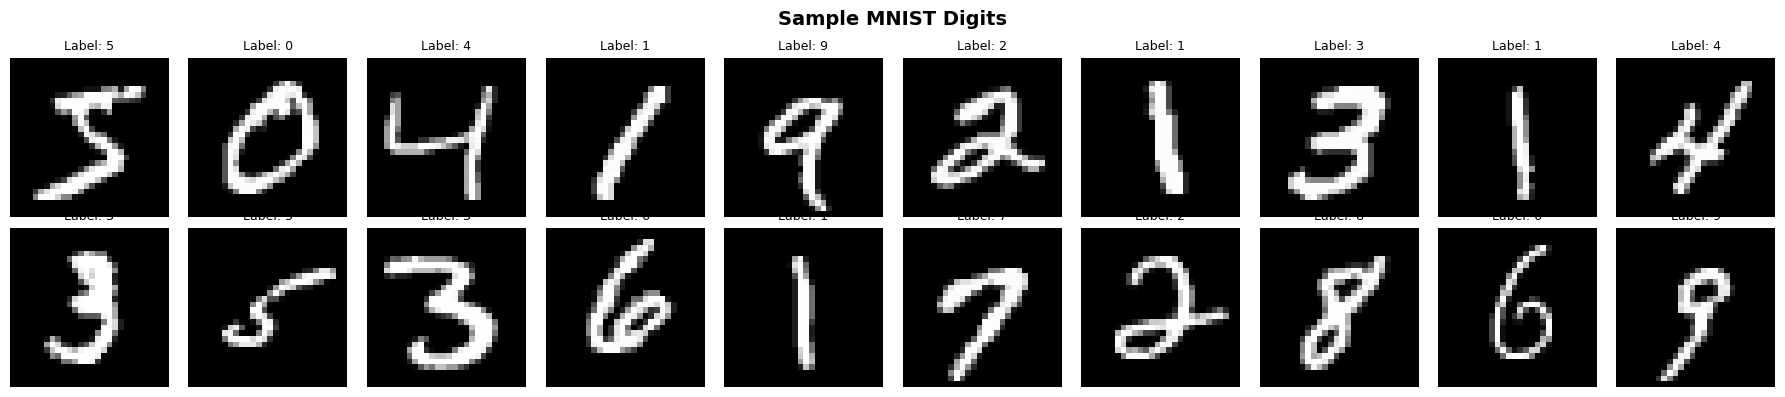

In [ ]:
# ============================================================
# BLOCK 2: Load & Preprocess Data
# ============================================================

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

# Reshape for CNN: (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train_raw, 10)
y_test  = to_categorical(y_test_raw,  10)

print(f"✅ Training samples : {X_train_cnn.shape[0]}")
print(f"✅ Test samples     : {X_test_cnn.shape[0]}")
print(f"✅ Input shape      : {X_train_cnn.shape[1:]}")
print(f"✅ Output classes   : {y_train.shape[1]}")

# Peek at some samples
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Sample MNIST Digits", fontsize=14, fontweight='bold')
for i in range(10):
    axes[0, i].imshow(X_train_raw[i], cmap='gray')
    axes[0, i].set_title(f"Label: {y_train_raw[i]}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train_raw[i+10], cmap='gray')
    axes[1, i].set_title(f"Label: {y_train_raw[i+10]}", fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOCK 3 (UPDATED): Model + Data Augmentation for Real-World Images
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def build_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Data Augmentation — teaches model to handle rotation, zoom, shift
datagen = ImageDataGenerator(
    rotation_range=10,        # slight rotations
    zoom_range=0.1,           # slight zoom
    width_shift_range=0.1,    # horizontal shift
    height_shift_range=0.1,   # vertical shift
    shear_range=0.1,          # slight shear
    fill_mode='nearest'
)
datagen.fit(X_train_cnn)

print("✅ Augmented model builder ready!")
sample_model = build_model()
sample_model.summary()

✅ Augmented model builder ready!


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,780,842 (6.79 MB)

 Trainable params: 1,779,882 (6.79 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# BLOCK 4 (UPDATED): Grid Search WITH Augmentation
# ============================================================

BATCH_SIZES = [32, 64, 128, 256]
EPOCH_SIZES = [10, 15, 20]

results = {}
total_runs = len(BATCH_SIZES) * len(EPOCH_SIZES)
run_num = 0

for batch_size, epochs in itertools.product(BATCH_SIZES, EPOCH_SIZES):
    run_num += 1
    key = (batch_size, epochs)
    print(f"\n{'='*60}")
    print(f"▶ Run {run_num}/{total_runs} | Batch={batch_size} | Epochs={epochs}")
    print(f"{'='*60}")

    model = build_model()

    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=0
    )

    # Use augmented data generator
    train_size = int(len(X_train_cnn) * 0.9)
    X_tr, X_val = X_train_cnn[:train_size], X_train_cnn[train_size:]
    y_tr, y_val = y_train[:train_size], y_train[train_size:]

    start = time.time()
    history = model.fit(
        datagen.flow(X_tr, y_tr, batch_size=batch_size),
        steps_per_epoch=len(X_tr) // batch_size,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    elapsed = time.time() - start

    train_loss, train_acc = model.evaluate(X_train_cnn, y_train, verbose=0)
    test_loss,  test_acc  = model.evaluate(X_test_cnn,  y_test,  verbose=0)

    results[key] = {
        'history'       : history.history,
        'train_acc'     : train_acc,
        'test_acc'      : test_acc,
        'train_loss'    : train_loss,
        'test_loss'     : test_loss,
        'time_sec'      : elapsed,
        'actual_epochs' : len(history.history['accuracy'])
    }

    print(f"  ✅ Train Acc : {train_acc*100:.2f}%")
    print(f"  ✅ Test  Acc : {test_acc*100:.2f}%")
    print(f"  ⏱  Time     : {elapsed:.1f}s")

print("\n\n🎉 Grid search complete!")


▶ Run 1/12 | Batch=32 | Epochs=10
Epoch 1/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.7684 - loss: 0.7465 - val_accuracy: 0.9877 - val_loss: 0.0410
Epoch 2/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step - accuracy: 1.0000 - loss: 0.0602 - val_accuracy: 0.9873 - val_loss: 0.0428
Epoch 3/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9544 - loss: 0.1549 - val_accuracy: 0.9877 - val_loss: 0.0435
Epoch 4/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 359us/step - accuracy: 1.0000 - loss: 0.0506 - val_accuracy: 0.9880 - val_loss: 0.0430
Epoch 5/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9681 - loss: 0.1115 - val_accuracy: 0.9913 - val_loss: 0.0294
Epoch 6/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.9912 - val_loss: 0.0295
Epoch 7/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9734 - loss: 0.0948 - val_accuracy: 0.9932 - val_loss: 0.0250
Epoch 8/10
1687/1687 ━━━━━━━━━━━━━━━━━━━━

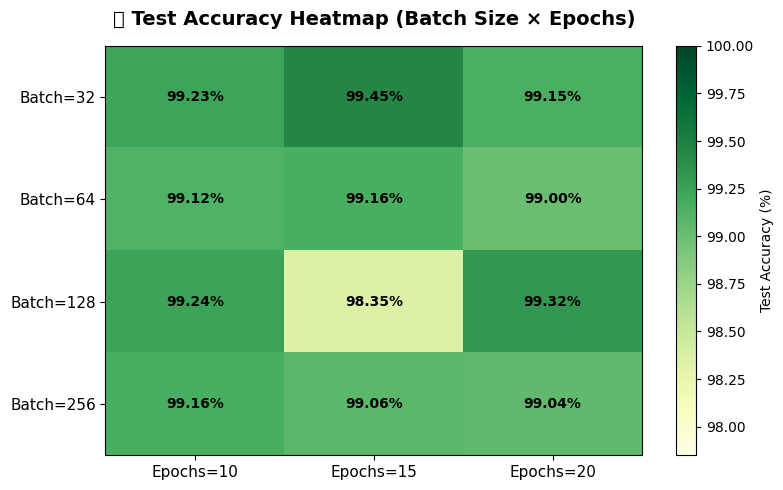

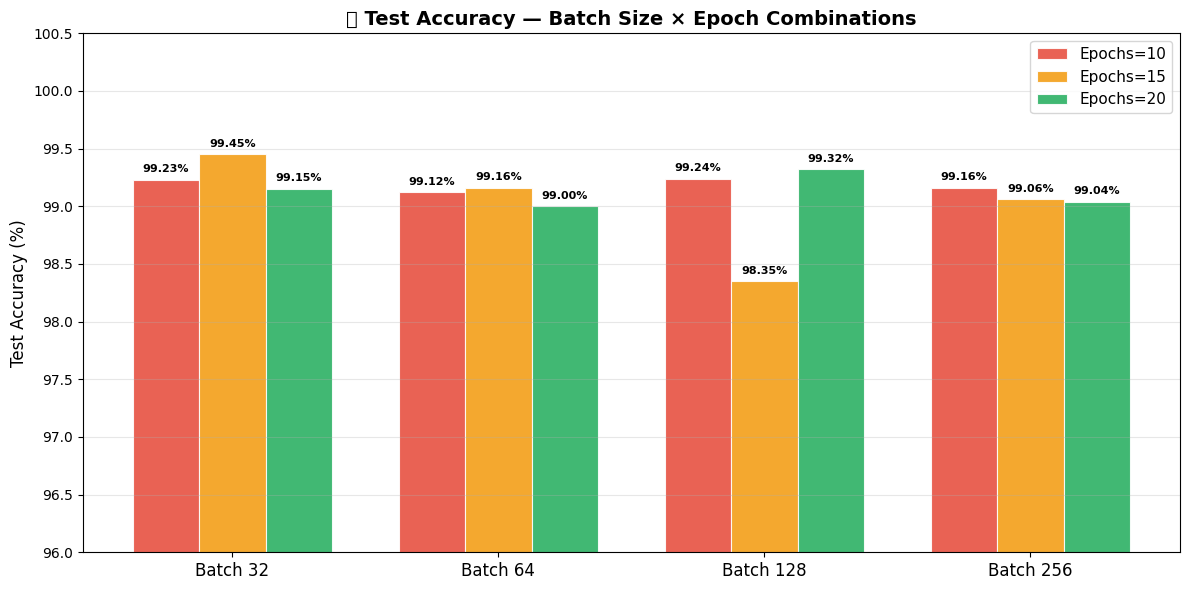

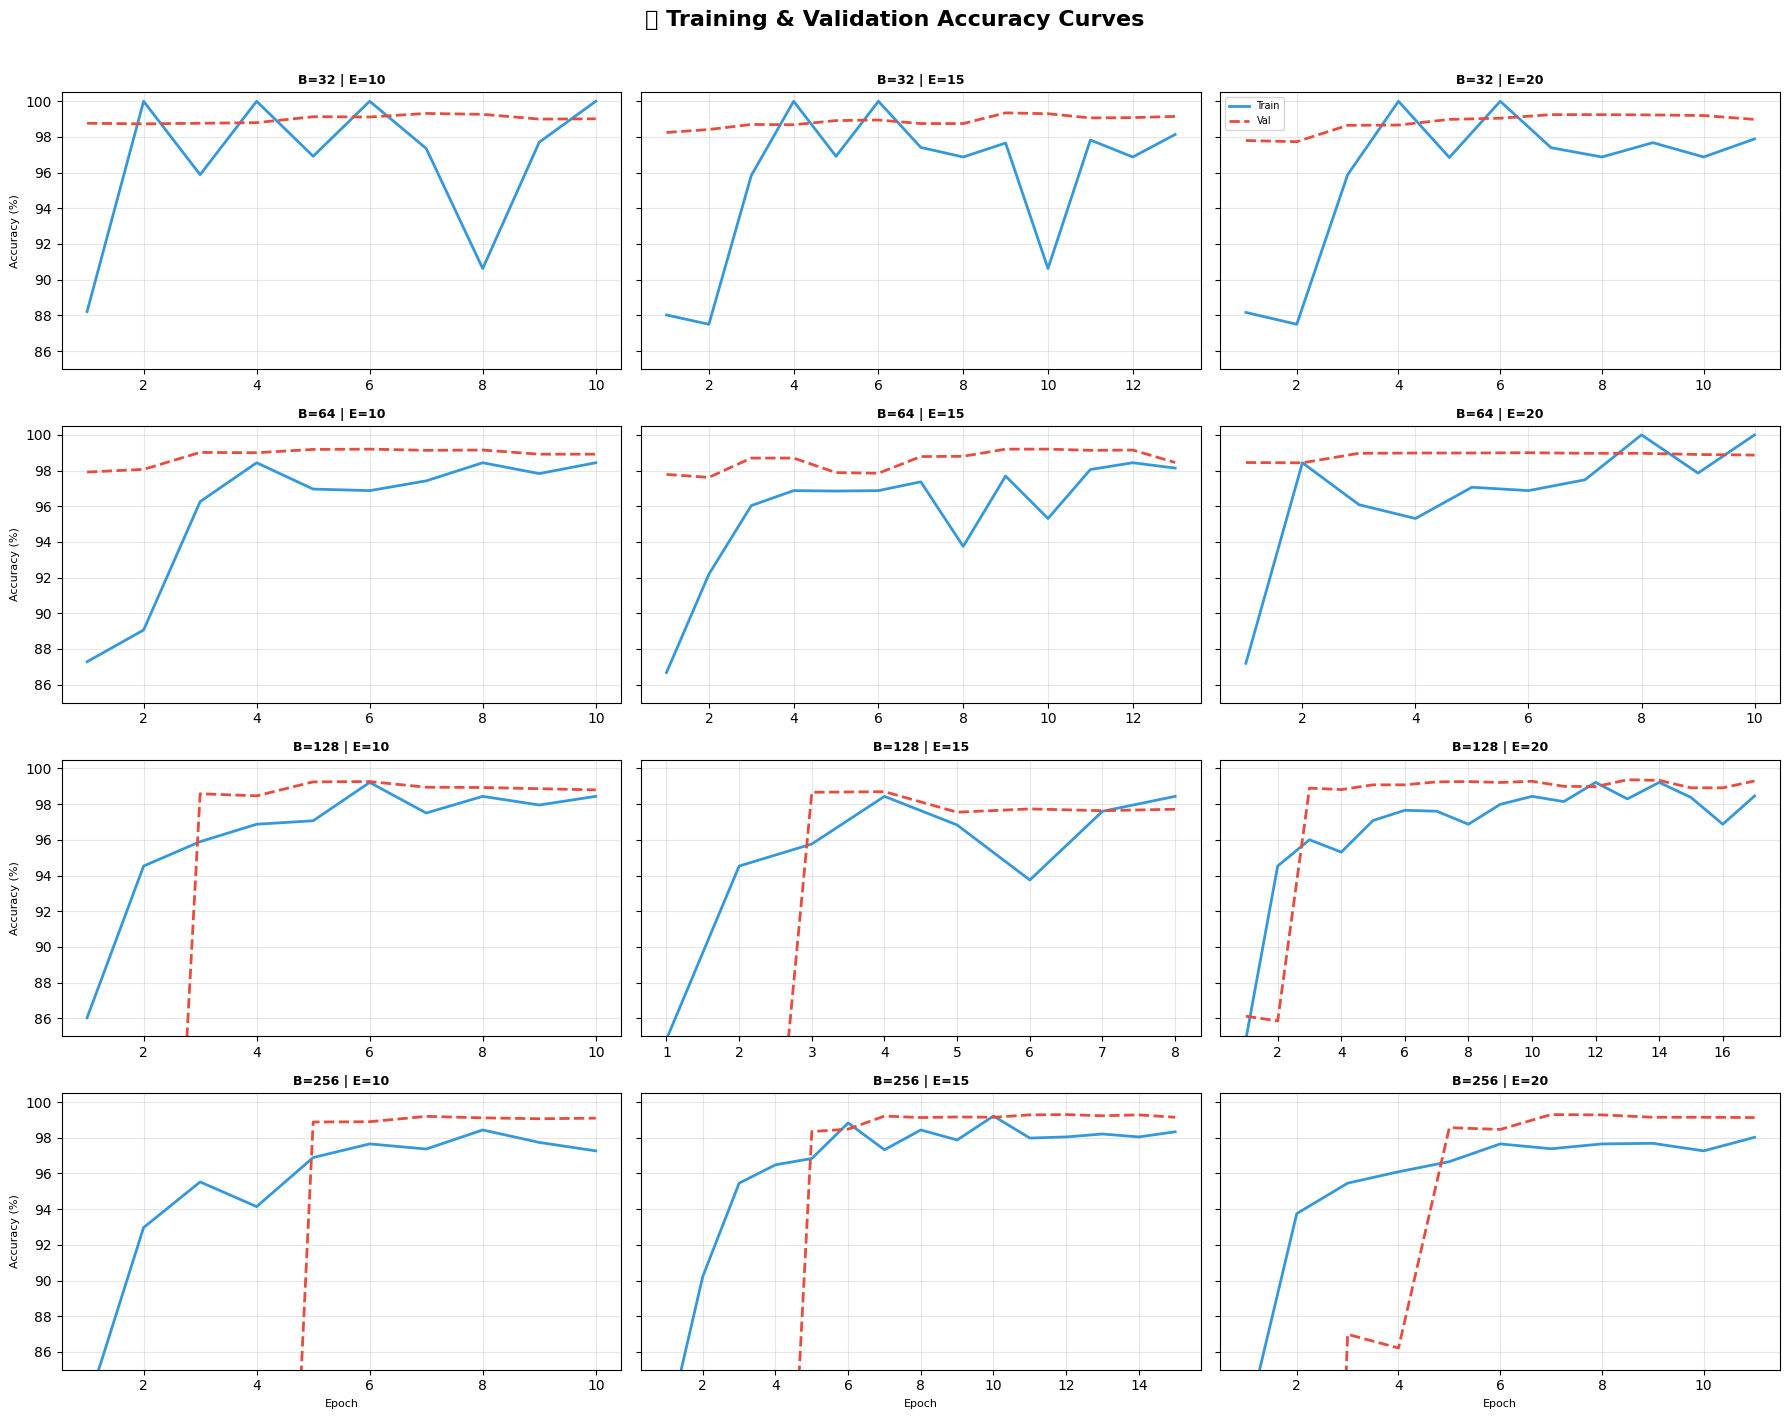

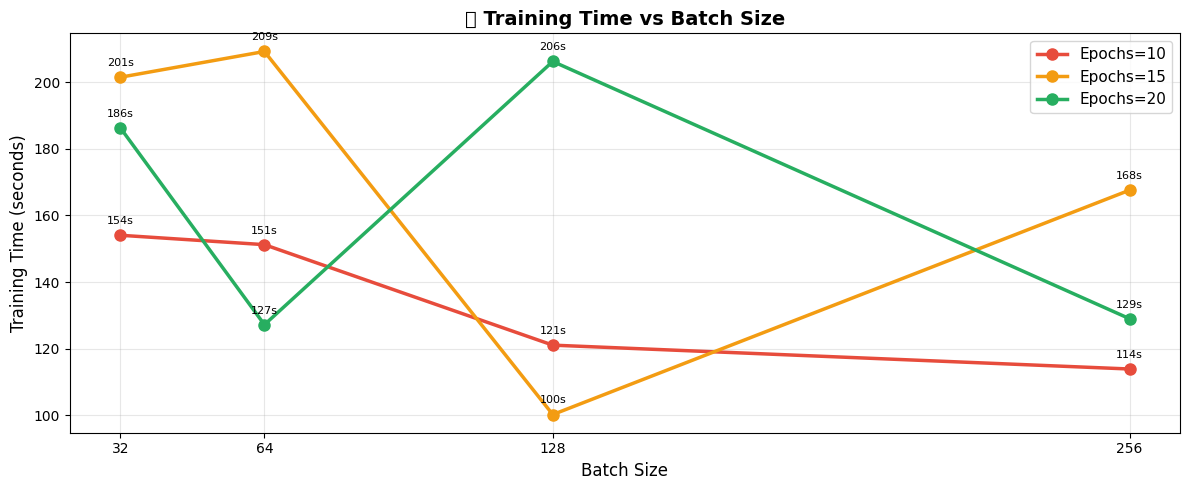


   Batch   Epochs    Train Acc     Test Acc   Time (s)  Actual Ep
      32       10       99.13%       99.23%     154.1s        10
      32       15       99.32%       99.45%     201.5s        13
      32       20       99.03%       99.15%     186.3s        11
      64       10       99.06%       99.12%     151.2s        10
      64       15       99.14%       99.16%     209.2s        13
      64       20       98.81%       99.00%     127.2s        10
     128       10       99.12%       99.24%     121.1s        10
     128       15       98.48%       98.35%     100.3s         8
     128       20       99.33%       99.32%     206.2s        17
     256       10       99.06%       99.16%     113.9s        10
     256       15       99.19%       99.06%     167.6s        15
     256       20       99.07%       99.04%     129.0s        11

🏆 Best Config: Batch=32, Epochs=15 → Test Acc=99.45%


In [ ]:
# ============================================================
# BLOCK 5: Comprehensive Visualization Dashboard
# ============================================================

# ── Helper: color palette per epoch size ──
EPOCH_COLORS = {10: '#E74C3C', 15: '#F39C12', 20: '#27AE60'}
BATCH_LABELS  = [str(b) for b in BATCH_SIZES]

# ─────────────────────────────────────────────────────────────
# CHART 1: Heatmap — Test Accuracy (Batch × Epoch)
# ─────────────────────────────────────────────────────────────
acc_matrix = np.array([
    [results[(b, e)]['test_acc'] * 100 for e in EPOCH_SIZES]
    for b in BATCH_SIZES
])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(acc_matrix, cmap='YlGn', aspect='auto', vmin=acc_matrix.min()-0.5, vmax=100)
plt.colorbar(im, ax=ax, label='Test Accuracy (%)')
ax.set_xticks(range(len(EPOCH_SIZES)))
ax.set_xticklabels([f'Epochs={e}' for e in EPOCH_SIZES], fontsize=11)
ax.set_yticks(range(len(BATCH_SIZES)))
ax.set_yticklabels([f'Batch={b}' for b in BATCH_SIZES], fontsize=11)
ax.set_title('🔥 Test Accuracy Heatmap (Batch Size × Epochs)', fontsize=14, fontweight='bold', pad=15)
for i in range(len(BATCH_SIZES)):
    for j in range(len(EPOCH_SIZES)):
        ax.text(j, i, f"{acc_matrix[i,j]:.2f}%",
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='black' if acc_matrix[i,j] > 98 else 'white')
plt.tight_layout()
plt.savefig('chart1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# CHART 2: Grouped Bar Chart — Test Accuracy per Batch & Epoch
# ─────────────────────────────────────────────────────────────
x   = np.arange(len(BATCH_SIZES))
w   = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
for idx, e in enumerate(EPOCH_SIZES):
    vals = [results[(b, e)]['test_acc'] * 100 for b in BATCH_SIZES]
    bars = ax.bar(x + idx*w, vals, w, label=f'Epochs={e}',
                  color=EPOCH_COLORS[e], alpha=0.88, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels([f'Batch {b}' for b in BATCH_SIZES], fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('📊 Test Accuracy — Batch Size × Epoch Combinations', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(min(acc_matrix.min() - 1, 96), 100.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# CHART 3: Training Curves — Accuracy per run (all 12 combos)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(BATCH_SIZES), len(EPOCH_SIZES),
                          figsize=(18, 14), sharex=False, sharey=True)
fig.suptitle('📈 Training & Validation Accuracy Curves', fontsize=16, fontweight='bold', y=1.01)

for i, batch_size in enumerate(BATCH_SIZES):
    for j, epochs in enumerate(EPOCH_SIZES):
        ax  = axes[i][j]
        h   = results[(batch_size, epochs)]['history']
        ep  = range(1, len(h['accuracy']) + 1)
        ax.plot(ep, [v*100 for v in h['accuracy']],     color='#3498DB', lw=2, label='Train')
        ax.plot(ep, [v*100 for v in h['val_accuracy']], color='#E74C3C', lw=2, linestyle='--', label='Val')
        ax.set_title(f'B={batch_size} | E={epochs}', fontsize=9, fontweight='bold')
        ax.set_ylim(85, 100.5)
        ax.grid(alpha=0.3)
        if i == len(BATCH_SIZES)-1: ax.set_xlabel('Epoch', fontsize=8)
        if j == 0:                  ax.set_ylabel('Accuracy (%)', fontsize=8)
        if i == 0 and j == len(EPOCH_SIZES)-1: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('chart3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# CHART 4: Training Time per Configuration
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for idx, e in enumerate(EPOCH_SIZES):
    times = [results[(b, e)]['time_sec'] for b in BATCH_SIZES]
    ax.plot(BATCH_SIZES, times, marker='o', lw=2.5, markersize=8,
            label=f'Epochs={e}', color=EPOCH_COLORS[e])
    for bx, ty in zip(BATCH_SIZES, times):
        ax.annotate(f'{ty:.0f}s', (bx, ty), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

ax.set_xlabel('Batch Size', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('⏱ Training Time vs Batch Size', fontsize=14, fontweight='bold')
ax.set_xticks(BATCH_SIZES)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# CHART 5: Summary Table
# ─────────────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Batch':>8} {'Epochs':>8} {'Train Acc':>12} {'Test Acc':>12} {'Time (s)':>10} {'Actual Ep':>10}")
print("="*75)
best_key, best_acc = None, 0
for b in BATCH_SIZES:
    for e in EPOCH_SIZES:
        r = results[(b, e)]
        marker = " ⭐" if r['test_acc'] > best_acc else ""
        if r['test_acc'] > best_acc:
            best_acc = r['test_acc']
            best_key = (b, e)
        print(f"{b:>8} {e:>8} {r['train_acc']*100:>11.2f}% {r['test_acc']*100:>11.2f}% "
              f"{r['time_sec']:>9.1f}s {r['actual_epochs']:>9}")
print("="*75)
print(f"\n🏆 Best Config: Batch={best_key[0]}, Epochs={best_key[1]} → Test Acc={best_acc*100:.2f}%")

In [ ]:
# ============================================================
# BLOCK 6 (UPDATED): Train Final Model with Augmentation
# ============================================================

BEST_BATCH  = best_key[0]
BEST_EPOCHS = best_key[1]

print(f"🏆 Training final model: Batch={BEST_BATCH}, Epochs={BEST_EPOCHS}")

final_model = build_model()

train_size  = int(len(X_train_cnn) * 0.9)
X_tr, X_val = X_train_cnn[:train_size], X_train_cnn[train_size:]
y_tr, y_val = y_train[:train_size], y_train[train_size:]

history_final = final_model.fit(
    datagen.flow(X_tr, y_tr, batch_size=BEST_BATCH),
    steps_per_epoch=len(X_tr) // BEST_BATCH,
    validation_data=(X_val, y_val),
    epochs=BEST_EPOCHS,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)],
    verbose=1
)

train_loss, train_acc = final_model.evaluate(X_train_cnn, y_train, verbose=0)
test_loss,  test_acc  = final_model.evaluate(X_test_cnn,  y_test,  verbose=0)
print(f"\n✅ Final Train Accuracy : {train_acc*100:.2f}%")
print(f"✅ Final Test  Accuracy : {test_acc*100:.2f}%")

final_model.save('mnist_final_model.h5')
print("\n💾 Model saved as: mnist_final_model.h5")

🏆 Training final model: Batch=32, Epochs=15
Epoch 1/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.7671 - loss: 0.7404 - val_accuracy: 0.9772 - val_loss: 0.0782
Epoch 2/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - accuracy: 1.0000 - loss: 0.0621 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 3/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9535 - loss: 0.1539 - val_accuracy: 0.9903 - val_loss: 0.0343
Epoch 4/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step - accuracy: 0.9688 - loss: 0.0711 - val_accuracy: 0.9905 - val_loss: 0.0340
Epoch 5/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9636 - loss: 0.1224 - val_accuracy: 0.9915 - val_loss: 0.0335
Epoch 6/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 1s 392us/step - accuracy: 1.0000 - loss: 0.0613 - val_accuracy: 0.9913 - val_loss: 0.0332
Epoch 7/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9751 - loss: 0.0870 - val_accuracy: 0.9865 - val_loss: 0.0538
Epoch 8/15
1687/1687 ━━━━━━━━━━━


✅ Final Train Accuracy : 99.44%
✅ Final Test  Accuracy : 99.35%

💾 Model saved as: mnist_final_model.h5


In [ ]:
# ============================================================
# BLOCK 7 (COMPLETELY REWRITTEN): Robust Prediction Engine
# ============================================================

def preprocess_image(image_input):
    """
    Robust preprocessing pipeline that handles:
    - Phone camera photos (black ink on white paper)
    - Varying lighting and shadows
    - Different image sizes
    Returns: (model_input, display_img_28x28)
    """

    # ── Step 1: Load as grayscale ──
    if isinstance(image_input, str):
        img_bgr = cv2.imread(image_input)
        gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    elif isinstance(image_input, np.ndarray):
        if image_input.ndim == 3:
            gray = cv2.cvtColor(image_input, cv2.COLOR_BGR2GRAY)
        else:
            gray = image_input.copy()
    else:
        gray = np.array(image_input.convert('L'))

    # ── Step 2: Resize large images for faster processing ──
    max_dim = 800
    h, w    = gray.shape
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        gray  = cv2.resize(gray, (int(w*scale), int(h*scale)))

    # ── Step 3: Adaptive thresholding (handles uneven lighting/shadows) ──
    # Much better than simple inversion for real phone photos
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    binary = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # invert: digit becomes WHITE on BLACK
        blockSize=15,             # neighborhood size
        C=8                       # constant subtracted from mean
    )

    # ── Step 4: Morphological cleanup — remove noise dots ──
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # ── Step 5: Find the largest connected component (the digit) ──
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        # Ignore background (label 0), find largest foreground blob
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        digit_mask = (labels == largest).astype(np.uint8) * 255

        # Also include components close to the largest (multi-stroke digits)
        largest_area = stats[largest, cv2.CC_STAT_AREA]
        for lbl in range(1, num_labels):
            if lbl != largest:
                area = stats[lbl, cv2.CC_STAT_AREA]
                if area > largest_area * 0.15:  # include if >15% of largest
                    digit_mask = cv2.bitwise_or(digit_mask, (labels == lbl).astype(np.uint8)*255)
    else:
        digit_mask = cleaned

    # ── Step 6: Crop tight bounding box with generous padding ──
    coords = cv2.findNonZero(digit_mask)
    if coords is not None:
        x, y, bw, bh = cv2.boundingRect(coords)
        # Make it square with padding
        side    = max(bw, bh)
        pad     = int(side * 0.35)     # 35% padding on each side
        cx, cy  = x + bw//2, y + bh//2
        x1 = max(0, cx - side//2 - pad)
        y1 = max(0, cy - side//2 - pad)
        x2 = min(digit_mask.shape[1], cx + side//2 + pad)
        y2 = min(digit_mask.shape[0], cy + side//2 + pad)
        cropped = digit_mask[y1:y2, x1:x2]
    else:
        cropped = digit_mask

    # ── Step 7: Resize to 28×28 using INTER_AREA for quality ──
    img_28 = cv2.resize(cropped, (28, 28), interpolation=cv2.INTER_AREA)

    # ── Step 8: Normalize & add slight sharpening ──
    img_28 = img_28.astype(np.float32) / 255.0

    # Normalize to roughly match MNIST pixel distribution
    # MNIST mean ≈ 0.13, std ≈ 0.31
    img_28 = np.clip(img_28, 0, 1)

    return img_28.reshape(1, 28, 28, 1), (img_28 * 255).astype(np.uint8)


def predict_digit(image_input, model=None):
    """Full prediction pipeline with visualization."""
    if model is None:
        model = final_model

    processed, display_img = preprocess_image(image_input)
    predictions = model.predict(processed, verbose=0)[0]

    predicted_digit = np.argmax(predictions)
    confidence      = predictions[predicted_digit] * 100

    # ── Load original for display ──
    if isinstance(image_input, str):
        orig_bgr = cv2.imread(image_input)
        orig     = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2GRAY)
    elif isinstance(image_input, np.ndarray):
        orig = image_input if image_input.ndim == 2 else cv2.cvtColor(image_input, cv2.COLOR_BGR2GRAY)
    else:
        orig = np.array(image_input.convert('L'))

    # ── Visualization ──
    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 2], wspace=0.35)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(orig, cmap='gray')
    ax0.set_title('📥 Input Image', fontsize=11, fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(display_img, cmap='gray')
    ax1.set_title('🔧 Preprocessed (28×28)', fontsize=11, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    colors = ['#E74C3C' if i == predicted_digit else '#BDC3C7' for i in range(10)]
    bars   = ax2.bar(range(10), predictions * 100, color=colors, edgecolor='white', lw=0.8)
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Digit Class', fontsize=10)
    ax2.set_ylabel('Confidence (%)', fontsize=10)
    ax2.set_title('📊 Class Probabilities', fontsize=11, fontweight='bold')
    ax2.set_ylim(0, 115)
    for bar, val in zip(bars, predictions * 100):
        if val > 1:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)
    ax2.grid(axis='y', alpha=0.3)

    # Confidence color coding
    conf_color = '#27AE60' if confidence >= 80 else '#F39C12' if confidence >= 50 else '#E74C3C'
    fig.suptitle(
        f'🔢 Predicted Digit: {predicted_digit}   |   Confidence: {confidence:.2f}%',
        fontsize=15, fontweight='bold', color=conf_color, y=1.03
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"  🔢 Predicted Digit  : {predicted_digit}")
    print(f"  📊 Confidence       : {confidence:.2f}%")
    print(f"  🥈 2nd Best         : {np.argsort(predictions)[-2]} "
          f"({predictions[np.argsort(predictions)[-2]]*100:.2f}%)")
    print(f"{'='*45}")

    return predicted_digit, confidence

print("✅ Fixed prediction engine ready!")

✅ Fixed prediction engine ready!


🧪 Testing on 10 random MNIST test images...



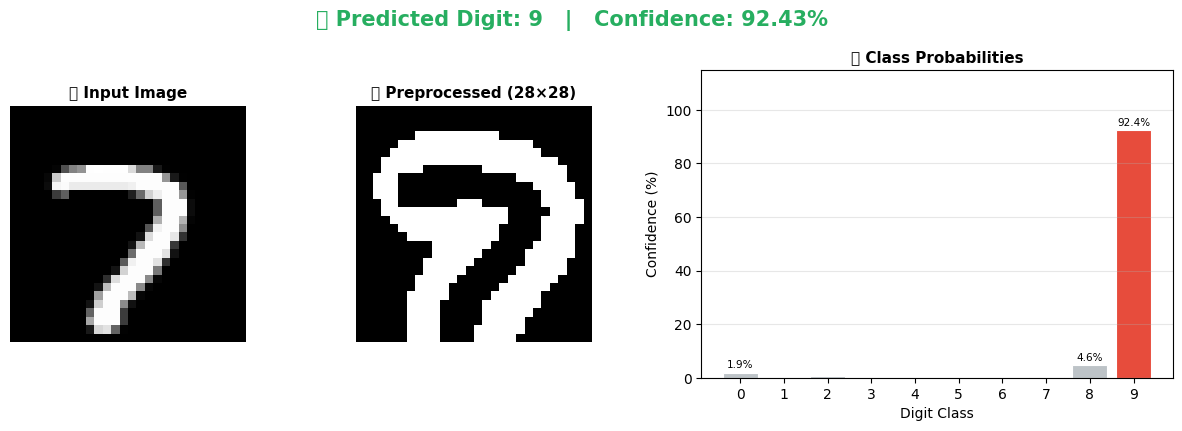


  🔢 Predicted Digit  : 9
  📊 Confidence       : 92.43%
  🥈 2nd Best         : 8 (4.59%)
  ❌ True: 7 | Predicted: 9 | Confidence: 92.4%



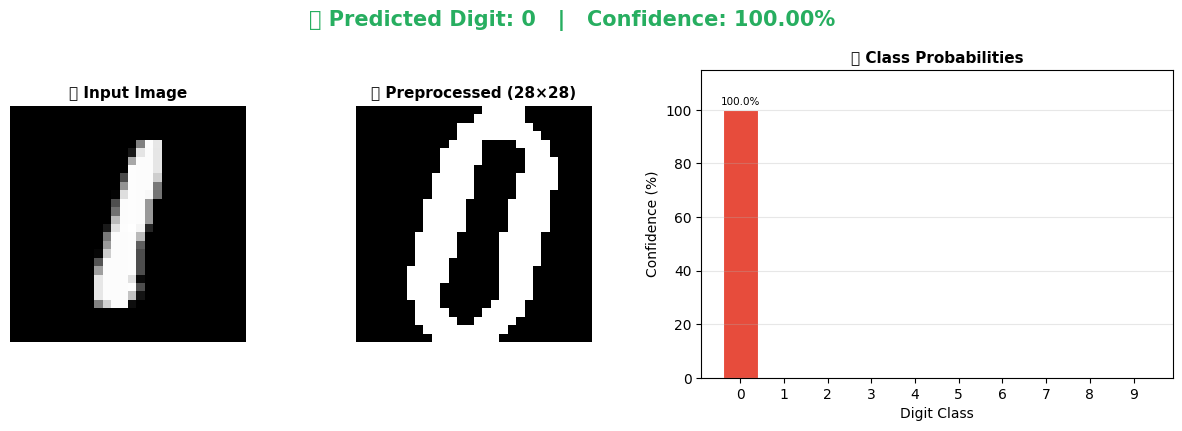


  🔢 Predicted Digit  : 0
  📊 Confidence       : 100.00%
  🥈 2nd Best         : 6 (0.00%)
  ❌ True: 1 | Predicted: 0 | Confidence: 100.0%



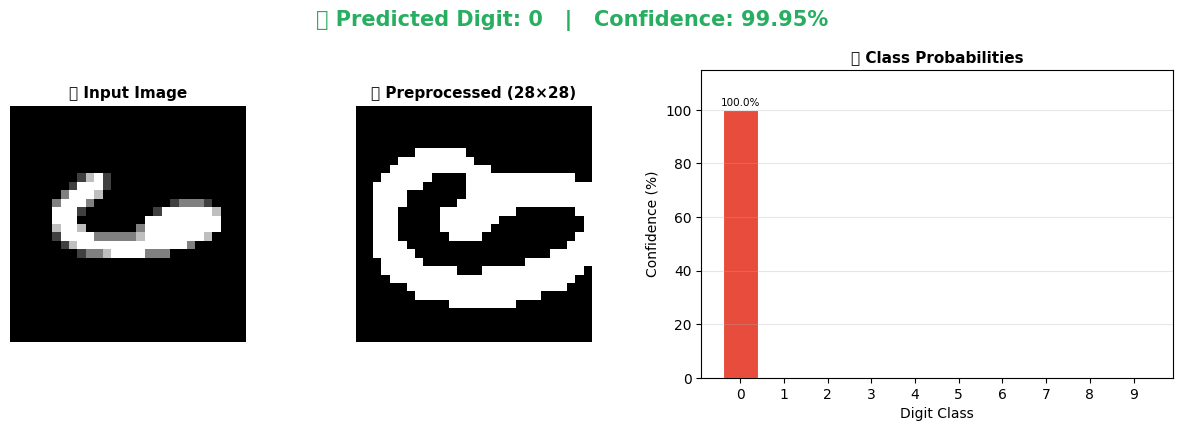


  🔢 Predicted Digit  : 0
  📊 Confidence       : 99.95%
  🥈 2nd Best         : 6 (0.03%)
  ❌ True: 6 | Predicted: 0 | Confidence: 100.0%



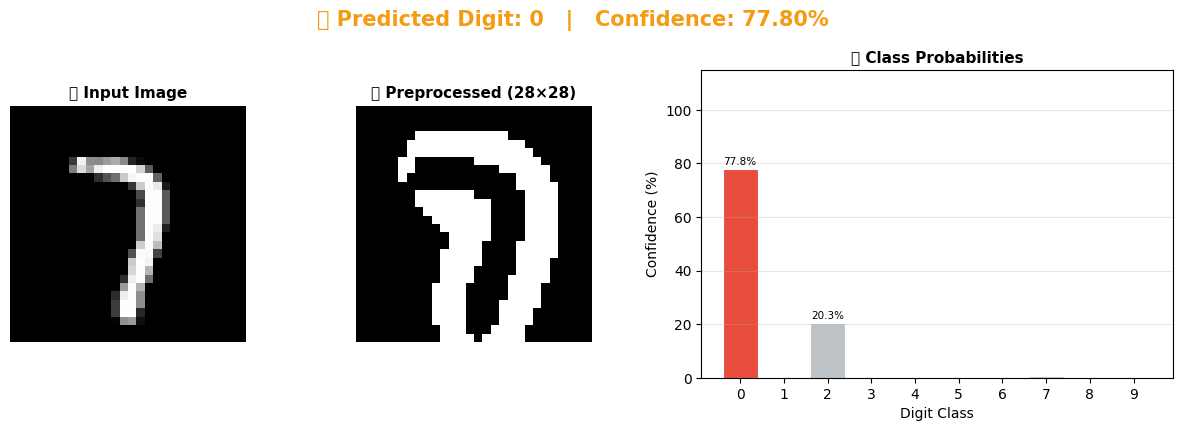


  🔢 Predicted Digit  : 0
  📊 Confidence       : 77.80%
  🥈 2nd Best         : 2 (20.31%)
  ❌ True: 7 | Predicted: 0 | Confidence: 77.8%



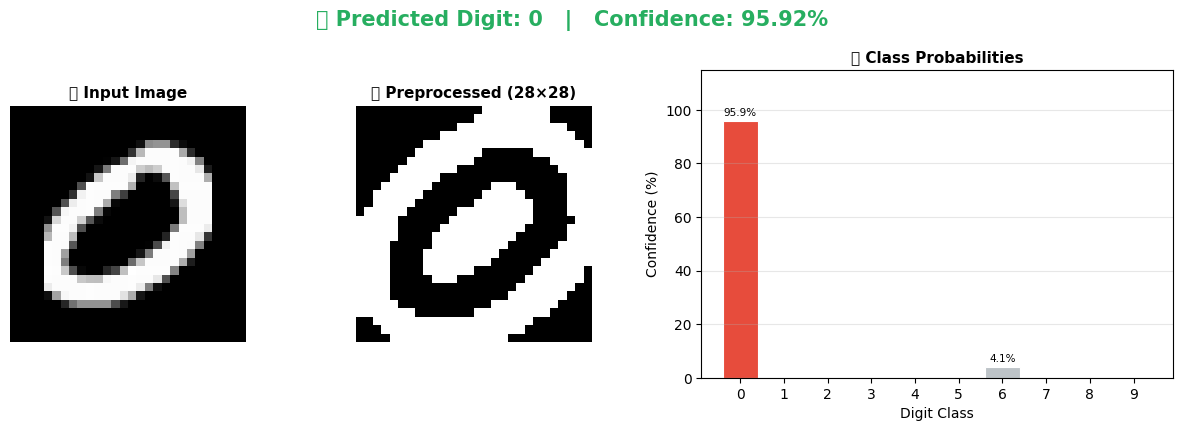


  🔢 Predicted Digit  : 0
  📊 Confidence       : 95.92%
  🥈 2nd Best         : 6 (4.07%)
  ✅ True: 0 | Predicted: 0 | Confidence: 95.9%



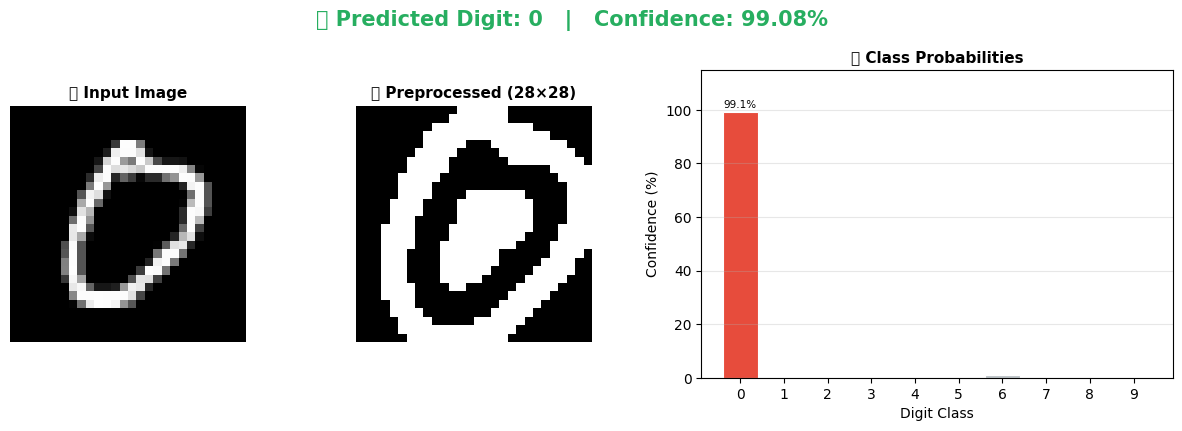


  🔢 Predicted Digit  : 0
  📊 Confidence       : 99.08%
  🥈 2nd Best         : 6 (0.91%)
  ✅ True: 0 | Predicted: 0 | Confidence: 99.1%



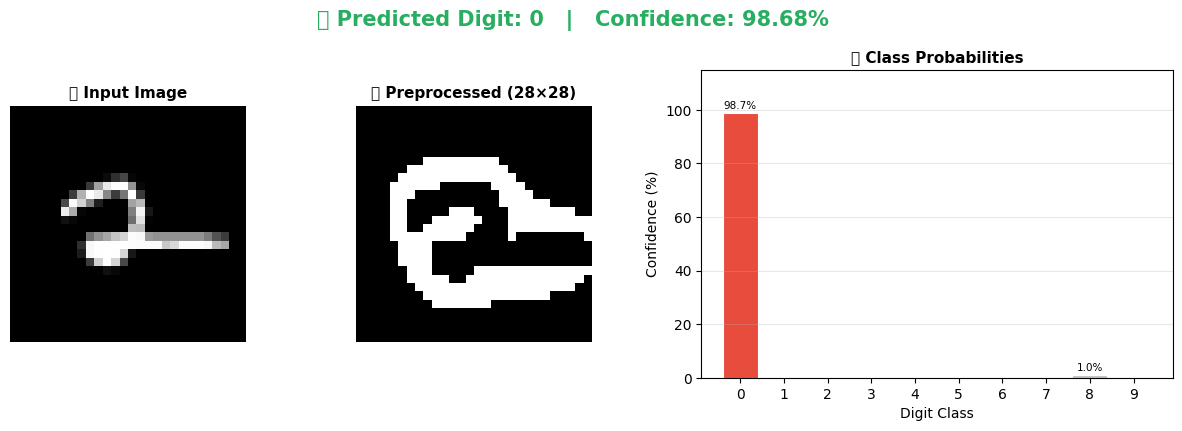


  🔢 Predicted Digit  : 0
  📊 Confidence       : 98.68%
  🥈 2nd Best         : 8 (1.01%)
  ❌ True: 2 | Predicted: 0 | Confidence: 98.7%



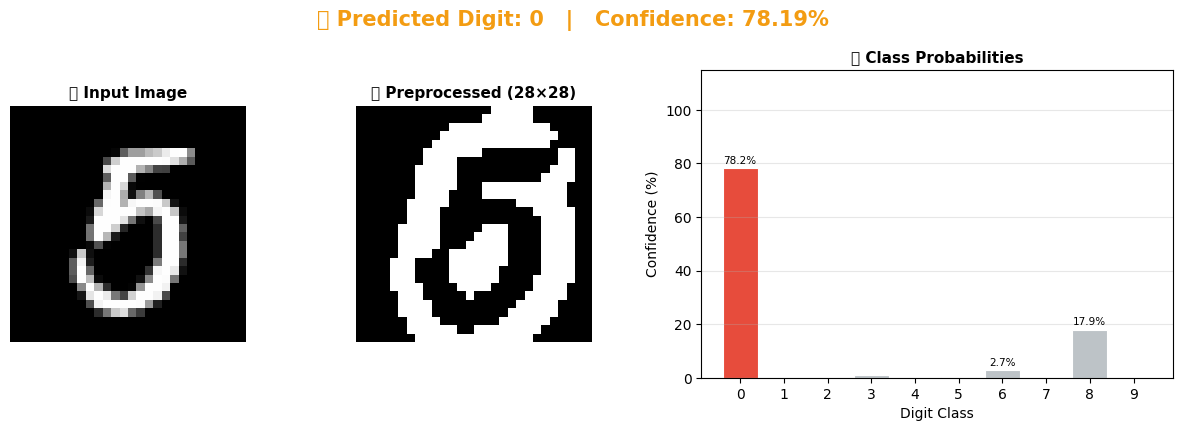


  🔢 Predicted Digit  : 0
  📊 Confidence       : 78.19%
  🥈 2nd Best         : 8 (17.88%)
  ❌ True: 5 | Predicted: 0 | Confidence: 78.2%



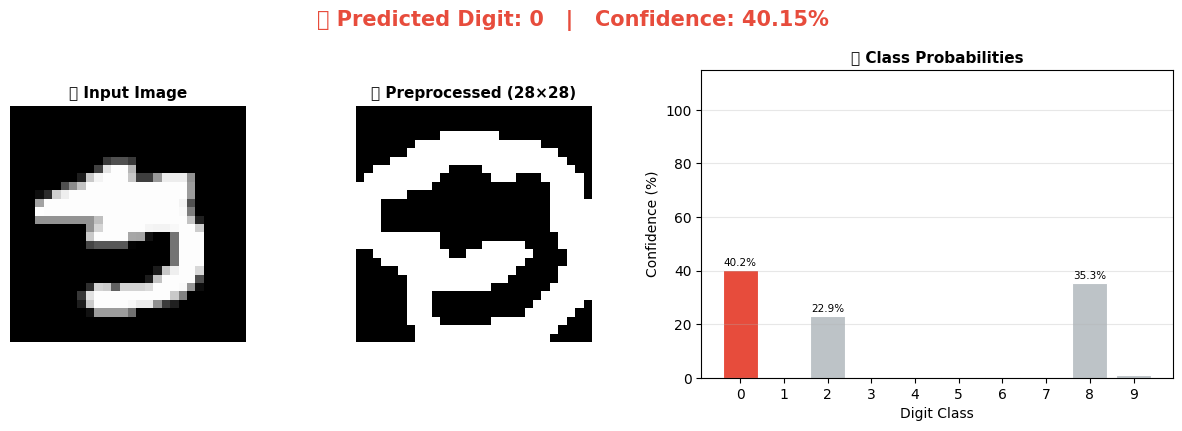


  🔢 Predicted Digit  : 0
  📊 Confidence       : 40.15%
  🥈 2nd Best         : 8 (35.28%)
  ❌ True: 3 | Predicted: 0 | Confidence: 40.2%



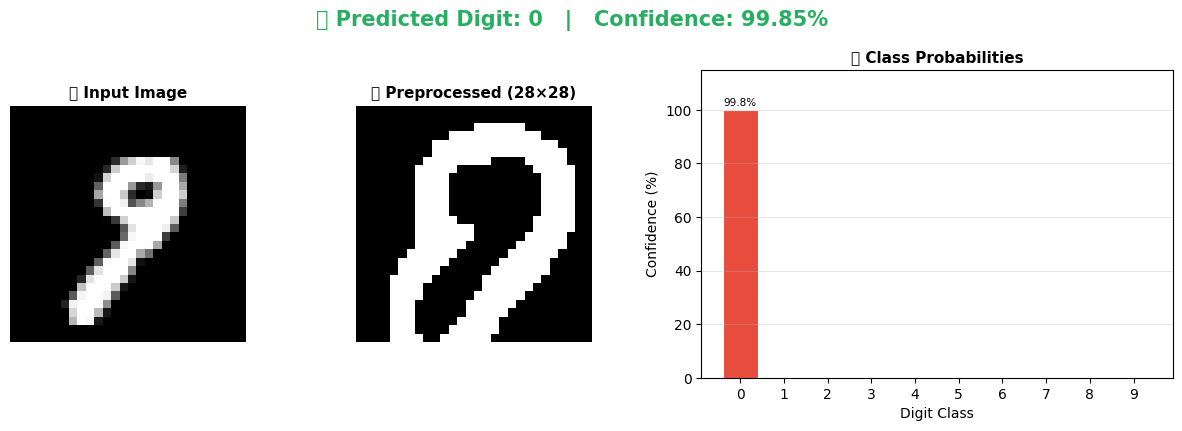


  🔢 Predicted Digit  : 0
  📊 Confidence       : 99.85%
  🥈 2nd Best         : 8 (0.14%)
  ❌ True: 9 | Predicted: 0 | Confidence: 99.8%


🎯 Accuracy on sampled batch: 2/10


In [ ]:
# ============================================================
# BLOCK 8: Sanity Check — Test on MNIST Test Samples
# ============================================================

print("🧪 Testing on 10 random MNIST test images...\n")
indices = np.random.choice(len(X_test_raw), 10, replace=False)

correct = 0
for idx in indices:
    img_array   = X_test_raw[idx]            # raw uint8 (28x28)
    true_label  = y_test_raw[idx]
    pred, conf  = predict_digit(img_array, model=final_model)
    status = "✅" if pred == true_label else "❌"
    print(f"  {status} True: {true_label} | Predicted: {pred} | Confidence: {conf:.1f}%\n")
    if pred == true_label:
        correct += 1

print(f"\n🎯 Accuracy on sampled batch: {correct}/10")

📤 Please upload an image of a handwritten digit (PNG/JPG/JPEG)...
   Tips for best results:
   • Write digit clearly on white paper
   • Good lighting, no heavy shadows
   • Crop close to the digit if possible



Saving WhatsApp Image 2026-03-09 at 5.13.05 PM (2).jpeg to WhatsApp Image 2026-03-09 at 5.13.05 PM (2) (2).jpeg

🖼  Processing: WhatsApp Image 2026-03-09 at 5.13.05 PM (2) (2).jpeg


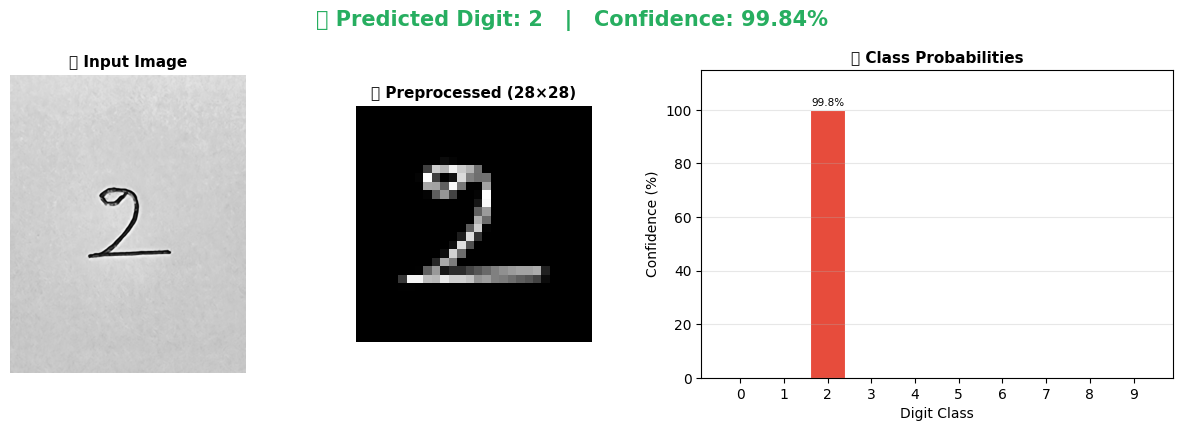


  🔢 Predicted Digit  : 2
  📊 Confidence       : 99.84%
  🥈 2nd Best         : 1 (0.12%)

🏁 FINAL RESULT
   The handwritten digit in 'WhatsApp Image 2026-03-09 at 5.13.05 PM (2) (2).jpeg' is: 2
   Confidence: 99.84%


In [ ]:
# ============================================================
# BLOCK 9: Upload & Predict Your Own Handwritten Digit Image
# ============================================================

from google.colab import files

print("📤 Please upload an image of a handwritten digit (PNG/JPG/JPEG)...")
print("   Tips for best results:")
print("   • Write digit clearly on white paper")
print("   • Good lighting, no heavy shadows")
print("   • Crop close to the digit if possible\n")

uploaded = files.upload()

for filename, content in uploaded.items():
    print(f"\n🖼  Processing: {filename}")

    # Save to disk temporarily
    with open(filename, 'wb') as f:
        f.write(content)

    # Predict
    predicted, confidence = predict_digit(filename, model=final_model)

    print(f"\n🏁 FINAL RESULT")
    print(f"   The handwritten digit in '{filename}' is: {predicted}")
    print(f"   Confidence: {confidence:.2f}%")